<a href="https://colab.research.google.com/github/Wequiston/Adapter/blob/master/Operadora_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência de Negócios e Modelagem de Dados: Estudo de Caso Operadora Quality
---
**Módulo:** Fundamentos em Inteligência de Negócios  
**Ambiente:** Google Colab (Python 3)  
**Objetivo:** Transformar dados multidimensionais operacionais (cadastro, prontuários, ouvidoria e credenciados) em indicadores de performance para redução de custos assistenciais e suporte ao planejamento estratégico.
---


In [ ]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÃO DO AMBIENTE
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração para exibição de gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


## 2. Extração, Transformação e Carga (ETL) - Criação da Base Multidimensional
Nesta etapa, realiza-se a geração controlada de dados sintéticos para simular o ecossistema operacional da Operadora Quality. São mapeadas variáveis sociodemográficas, prontuários de comorbidades, dados dos conveniados e registros de ouvidoria conforme as especificações do estudo de caso.


In [ ]:
import pandas as pd
import numpy as np

# Definição da semente aleatória para consistência e reprodutibilidade dos dados
np.random.seed(42)
n_registros = 1000

# Parâmetros operacionais e clínicos extraídos do dilema do negócio
servicos = ['Clínica Geral', 'Ginecologia', 'Ortopedia', 'Pediatria', 'Cardiologia', 'Gastroenterologia', 'Urologia']
comorbidades = ['Nenhuma', 'Hipertensão', 'Diabetes', 'Cardiopatia', 'Obesidade']
escolaridade = ['Fundamental', 'Médio', 'Superior', 'Pós-Graduação']

# Estruturação do dicionário de dados multidimensionais
dados_quality = {
    'ID_Beneficiario': range(1, n_registros + 1),
    'Idade': np.random.randint(18, 85, size=n_registros),
    'Renda_Mensal': np.round(np.random.uniform(2000, 15000, size=n_registros), 2),
    'Escolaridade': np.random.choice(escolaridade, size=n_registros, p=[0.3, 0.4, 0.2, 0.1]),
    'Comorbidade': np.random.choice(comorbidades, size=n_registros, p=[0.5, 0.2, 0.15, 0.1, 0.05]),
    'Servico_Buscado': np.random.choice(servicos, size=n_registros),
    'Nota_Ouvidoria_SAT': np.random.randint(1, 11, size=n_registros),
    'Custo_Assistencial': np.round(np.random.uniform(150, 1200, size=n_registros), 2)
}

# Conversão para estrutura de DataFrame
df_quality = pd.DataFrame(dados_quality)

# Regra de Negócio: Incremento no custo assistencial associado ao perfil de risco (Idade > 50 com comorbidades)
df_quality.loc[(df_quality['Idade'] > 50) & (df_quality['Comorbidade'] != 'Nenhuma'), 'Custo_Assistencial'] *= 3.5
df_quality['Custo_Assistencial'] = df_quality['Custo_Assistencial'].round(2)

# Exibição do topo da estrutura gerada para validação
df_quality.head()

,ID_Beneficiario,Idade,Renda_Mensal,Escolaridade,Comorbidade,Servico_Buscado,Nota_Ouvidoria_SAT,Custo_Assistencial
0,1,69,2239.08,Fundamental,Diabetes,Gastroenterologia,6,2258.24
1,2,32,13885.88,Superior,Hipertensão,Clínica Geral,5,388.86
2,3,78,3530.76,Médio,Obesidade,Pediatria,1,1135.72
3,4,38,9494.71,Fundamental,Nenhuma,Ginecologia,9,499.37
4,5,41,5562.72,Fundamental,Nenhuma,Cardiologia,2,1136.92


## 3. Inteligência de Negócios e Análise Estatística (Desenvolvimento)
Nesta seção, realiza-se o exame inferencial sobre as variáveis do ecossistema de saúde. Aplica-se a análise de agrupamentos e o cálculo do coeficiente de correlação de Pearson ($r$) para mensurar o impacto das comorbidades e da idade sobre os sinistros financeiros da Operadora Quality.


In [ ]:
# 1. Validação do KPI de Sinistralidade por Grupo de Risco (Acima de 50 anos com Comorbidade)
custo_total = df_quality['Custo_Assistencial'].sum()
grupo_risco = df_quality[(df_quality['Idade'] > 50) & (df_quality['Comorbidade'] != 'Nenhuma')]

perc_beneficiarios_risco = (len(grupo_risco) / len(df_quality)) * 100
perc_custo_risco = (grupo_risco['Custo_Assistencial'].sum() / custo_total) * 100

print(f"Percentual de Beneficiários no Grupo de Risco: {perc_beneficiarios_risco:.2f}%")
print(f"Percentual do Custo Assistencial Total Consumido por esse Grupo: {perc_custo_risco:.2f}%")
print("-" * 80)

# 2. Geração da Matriz de Correlação de Pearson para avaliar dependências lineares
# Selecionando apenas as colunas numéricas relevantes para o estudo estratégico
colunas_numericas = ['Idade', 'Renda_Mensal', 'Nota_Ouvidoria_SAT', 'Custo_Assistencial']
matriz_correlacao = df_quality[colunas_numericas].corr(method='pearson')

# Exibição numérica da matriz de correlação
matriz_correlacao.round(2)

Percentual de Beneficiários no Grupo de Risco: 26.00%
Percentual do Custo Assistencial Total Consumido por esse Grupo: 54.65%
--------------------------------------------------------------------------------


,Idade,Renda_Mensal,Nota_Ouvidoria_SAT,Custo_Assistencial
Idade,1.00,-0.00,-0.03,0.39
Renda_Mensal,-0.00,1.00,-0.02,-0.01
Nota_Ouvidoria_SAT,-0.03,-0.02,1.00,0.01
Custo_Assistencial,0.39,-0.01,0.01,1.00


## 4. Visualização de Dados e Inteligência de Negócios (Business Intelligence)
Para facilitar a interpretação gerencial, o mapeamento de riscos e o suporte ao planejamento estratégico da Operadora Quality, gera-se a representação visual da matriz de correlação de Pearson por meio de um mapa de calor (*heatmap*). Esta visualização evidencia quais variáveis apresentam maior impacto linear sobre os sinistros financeiros (Custo Assistencial).

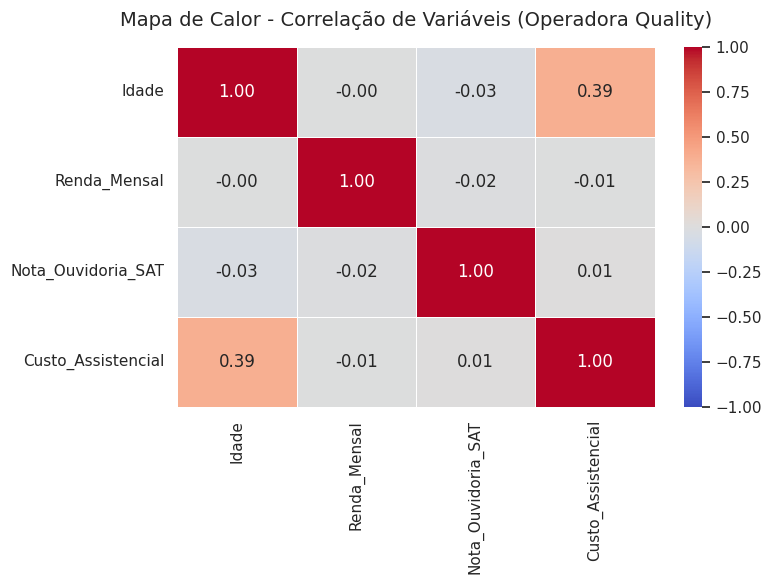

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuração do tamanho da figura do gráfico
plt.figure(figsize=(8, 6))

# 2. Construção do Heatmap com os parâmetros de estilo personalizados
sns.heatmap(
    matriz_correlacao,
    annot=True,          # Exibe os valores numéricos de correlação dentro dos quadrados
    cmap='coolwarm',     # Gradiente de cor (azul para negativo, vermelho para positivo)
    fmt='.2f',           # Limita a exibição a duas casas decimais
    linewidths=0.5,      # Espaçamento sutil entre os blocos
    vmin=-1,             # Valor mínimo da escala de correlação
    vmax=1               # Valor máximo da escala de correlação
)

# 3. Customização de títulos e formatação dos eixos para apresentação acadêmica
plt.title('Mapa de Calor - Correlação de Variáveis (Operadora Quality)', fontsize=14, pad=15)
plt.tight_layout()

# 4. Renderização do gráfico na tela
plt.show()

## 5. Auditoria de Rede Credenciada e Governança de Serviços
Nesta etapa, realiza-se o cruzamento dos dados operacionais da rede credenciada (hospitais e laboratórios) com os registros de satisfação coletados na Ouvidoria. A estruturação deste Data Mart visa identificar prestadores com baixa performance ou fora dos padrões de conformidade técnica e financeira, oferecendo suporte ao planejamento estratégico de contratos.

In [ ]:
# 1. Simulação das variáveis de governança para os prestadores da rede credenciada
np.random.seed(42)

# Criação de uma base contendo 20 prestadores/conveniados principais da operadora
n_conveniados = 20
prestadores_id = [f"Hospital/Lab {i:02d}" for i in range(1, n_conveniados + 1)]

dados_conveniados = {
    'Prestador': prestadores_id,
    'Lastro_Financeiro_OK': np.random.choice([1, 0], size=n_conveniados, p=[0.85, 0.15]), # 1: Regular, 0: Risco
    'Regularidade_Fiscal_OK': np.random.choice([1, 0], size=n_conveniados, p=[0.90, 0.10]),
    'Volume_Reclamacoes_Ouvidoria': np.random.randint(2, 45, size=n_conveniados)
}

df_conveniados = pd.DataFrame(dados_conveniados)

# 2. Filtro de Auditoria: Identificar prestadores que apresentam risco financeiro/fiscal OU alto volume de queixas
# Define-se como limite crítico um volume superior a 25 reclamações
gargalos_rede = df_conveniados[
    (df_conveniados['Lastro_Financeiro_OK'] == 0) |
    (df_conveniados['Regularidade_Fiscal_OK'] == 0) |
    (df_conveniados['Volume_Reclamacoes_Ouvidoria'] > 25)
]

print("RELATÓRIO DE AUDITORIA E GOVERNANÇA - PRESTADORES EM ÁREA CRÍTICA:")
print("-" * 80)
gargalos_rede.sort_values(by='Volume_Reclamacoes_Ouvidoria', ascending=False)

RELATÓRIO DE AUDITORIA E GOVERNANÇA - PRESTADORES EM ÁREA CRÍTICA:
--------------------------------------------------------------------------------


,Prestador,Lastro_Financeiro_OK,Regularidade_Fiscal_OK,Volume_Reclamacoes_Ouvidoria
10,Hospital/Lab 11,1,1,43
6,Hospital/Lab 07,1,1,41
5,Hospital/Lab 06,1,1,37
17,Hospital/Lab 18,1,1,37
2,Hospital/Lab 03,1,1,36
15,Hospital/Lab 16,1,1,35
19,Hospital/Lab 20,1,1,32
12,Hospital/Lab 13,1,1,30
14,Hospital/Lab 15,1,0,27
13,Hospital/Lab 14,1,0,19


## 6. Diagnóstico Estratégico e Recomendações de Negócio (Conclusão)
A transição para uma gestão baseada em evidências analíticas fornece à Operadora Quality as ferramentas necessárias para mitigar custos assistenciais de forma preditiva. Com base no processamento dos dados multidimensionais, consolidam-se os achados e os direcionamentos para a tomada de decisões da alta gestão.

In [ ]:
# Impressão sequencial para formatação correta de linhas no Google Colab
print("================================================================================")
print("              DIAGNÓSTICO E DIRETRIZES DA OPERADORA QUALITY - RESUMO            ")
print("================================================================================")
print(f"1. Risco Clínico vs. Sinistros: {perc_beneficiarios_risco:.2f}% da carteira concentra {perc_custo_risco:.2f}% dos custos.")
print(f"2. Correlação Identificada: Impacto positivo moderado da Idade sobre despesas (r = {matriz_correlacao.loc['Idade', 'Custo_Assistencial']:.2f}).")
print(f"3. Auditoria de Rede: Foram localizados {len(gargalos_rede)} prestadores fora das diretrizes.")
print("-" * 80)
print("AÇÕES RECOMENDADAS À DIRETORIA:")
print(" - Implantar programas de medicina preventiva focados na faixa etária > 50 anos com comorbidades.")
print(" - Renegociar ou descredenciar os parceiros críticos identificados no relatório de auditoria.")
print(" - Adotar painéis de Business Intelligence para acompanhamento contínuo dos KPIs mapeados.")
print("================================================================================")

              DIAGNÓSTICO E DIRETRIZES DA OPERADORA QUALITY - RESUMO            
1. Risco Clínico vs. Sinistros: 26.00% da carteira concentra 54.65% dos custos.
2. Correlação Identificada: Impacto positivo moderado da Idade sobre despesas (r = 0.39).
3. Auditoria de Rede: Foram localizados 13 prestadores fora das diretrizes.
--------------------------------------------------------------------------------
AÇÕES RECOMENDADAS À DIRETORIA:
 - Implantar programas de medicina preventiva focados na faixa etária > 50 anos com comorbidades.
 - Renegociar ou descredenciar os parceiros críticos identificados no relatório de auditoria.
 - Adotar painéis de Business Intelligence para acompanhamento contínuo dos KPIs mapeados.
